In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd

# Adjust the path below if your file is in a different location within your Google Drive
file_path = '/content/drive/MyDrive/mgsc 310/final project/heart_2020_cleaned.csv'
df = pd.read_csv(file_path)
display(df.head())

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [4]:
# Check for any missing values (the 'cleaned' version should have none)
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "  None")

Missing values per column:
  None


In [5]:
# This dataset has many duplicate rows because BRFSS uses a finite set
# of categorical responses. We are going to drop them to prevent train/test leakage.
n_dups = df.duplicated().sum()
print(f"Duplicate rows: {n_dups:,} ({n_dups / len(df) * 100:.1f}%)")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after dropping duplicates: {df.shape}")

Duplicate rows: 18,078 (5.7%)
Shape after dropping duplicates: (301717, 18)


Counts:
HeartDisease
No     274456
Yes     27261
Name: count, dtype: int64

Proportions:
HeartDisease
No     0.9096
Yes    0.0904
Name: proportion, dtype: float64


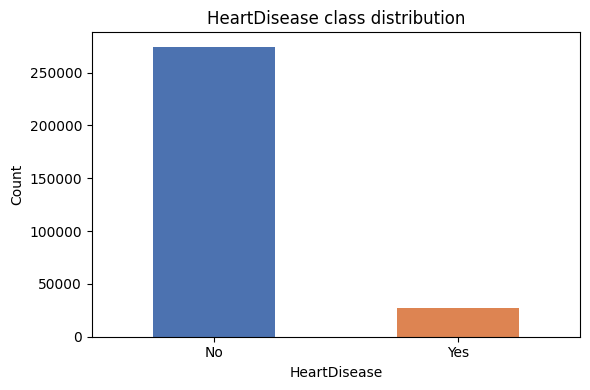

In [6]:
import matplotlib.pyplot as plt

# class imbalance
counts = df["HeartDisease"].value_counts()
proportions = df["HeartDisease"].value_counts(normalize=True)
print("Counts:")
print(counts)
print("\nProportions:")
print(proportions.round(4))

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("HeartDisease class distribution")
ax.set_xlabel("HeartDisease")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

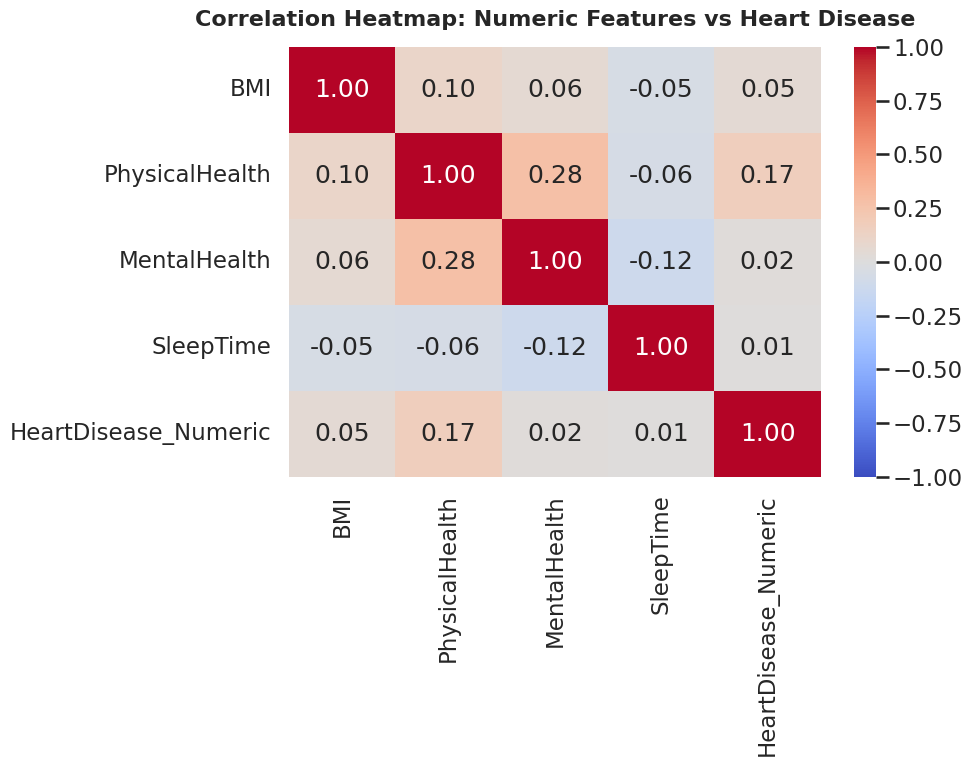

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Correlation Heatmap of Numeric Features
df_eda = df.copy()
df_eda['HeartDisease_Numeric'] = (df_eda['HeartDisease'] == 'Yes').astype(int)
numeric_features = df_eda.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(df_eda[numeric_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap: Numeric Features vs Heart Disease', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("presentation_correlation_heatmap.png", dpi=300)
plt.show()

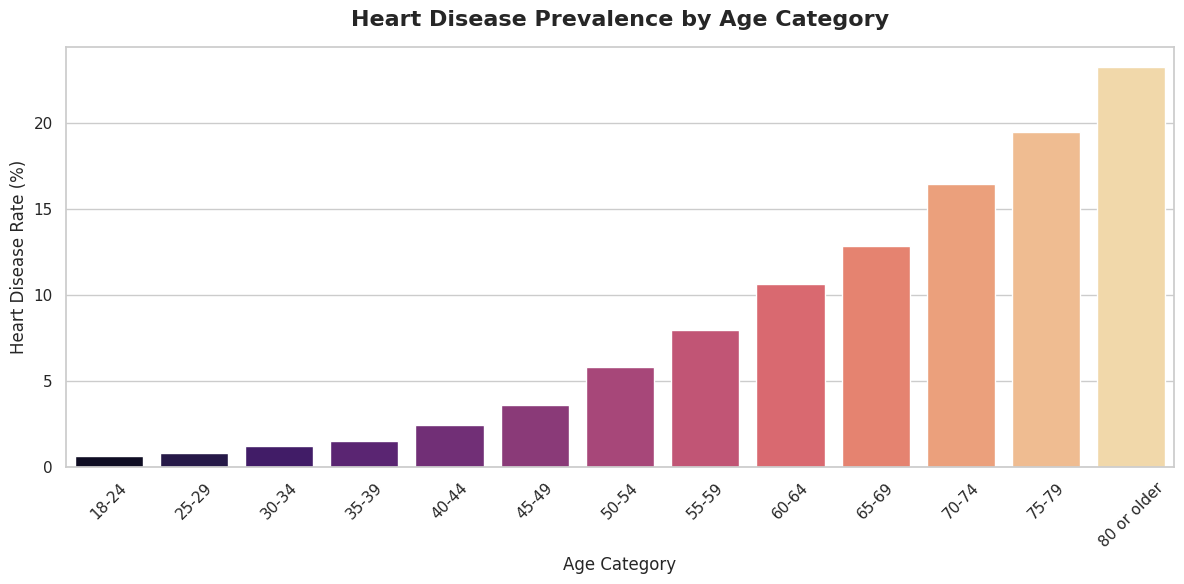

In [76]:
# 2. Heart Disease Prevalence by Age Category
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Calculate percentage of Heart Disease = 'Yes' for each age group
age_order = sorted(df['AgeCategory'].unique())
age_props = df.groupby('AgeCategory')['HeartDisease'].apply(lambda x: (x == 'Yes').mean() * 100).reindex(age_order).reset_index(name='HD_Percentage')

sns.barplot(data=age_props, x='AgeCategory', y='HD_Percentage', palette='magma')
plt.title('Heart Disease Prevalence by Age Category', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Age Category', fontsize=12)
plt.ylabel('Heart Disease Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("presentation_hd_by_age.png", dpi=300)
plt.show()

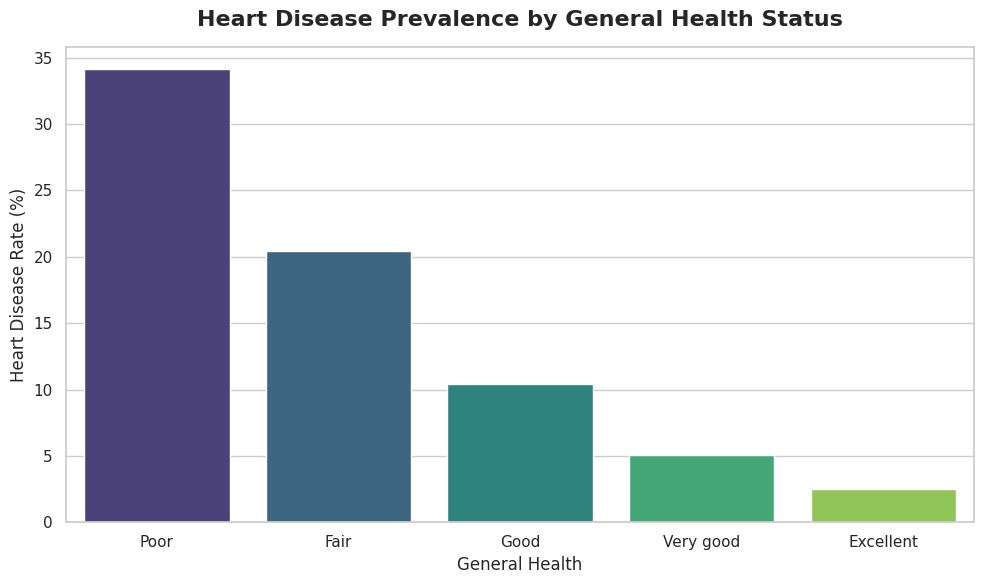

In [77]:
# 3. Heart Disease Prevalence by General Health
plt.figure(figsize=(10, 6))

# Calculate percentage of Heart Disease = 'Yes' for each health status
health_order = ['Poor', 'Fair', 'Good', 'Very good', 'Excellent']
health_props = df.groupby('GenHealth')['HeartDisease'].apply(lambda x: (x == 'Yes').mean() * 100).reindex(health_order).reset_index(name='HD_Percentage')

sns.barplot(data=health_props, x='GenHealth', y='HD_Percentage', palette='viridis')
plt.title('Heart Disease Prevalence by General Health Status', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('General Health', fontsize=12)
plt.ylabel('Heart Disease Rate (%)', fontsize=12)
plt.tight_layout()
plt.savefig("presentation_hd_by_genhealth.png", dpi=300)
plt.show()

In [7]:
import numpy as np
# Look at every categorical column's unique values
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
cat_cols.remove("HeartDisease")
print(f"Categorical features ({len(cat_cols)}): {cat_cols}\n")

for col in cat_cols:
    vals = df[col].unique().tolist()
    print(f"{col} ({len(vals)} values): {sorted(vals)}")

Categorical features (13): ['Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'Sex', 'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'Asthma', 'KidneyDisease', 'SkinCancer']

Smoking (2 values): ['No', 'Yes']
AlcoholDrinking (2 values): ['No', 'Yes']
Stroke (2 values): ['No', 'Yes']
DiffWalking (2 values): ['No', 'Yes']
Sex (2 values): ['Female', 'Male']
AgeCategory (13 values): ['18-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80 or older']
Race (6 values): ['American Indian/Alaskan Native', 'Asian', 'Black', 'Hispanic', 'Other', 'White']
Diabetic (4 values): ['No', 'No, borderline diabetes', 'Yes', 'Yes (during pregnancy)']
PhysicalActivity (2 values): ['No', 'Yes']
GenHealth (5 values): ['Excellent', 'Fair', 'Good', 'Poor', 'Very good']
Asthma (2 values): ['No', 'Yes']
KidneyDisease (2 values): ['No', 'Yes']
SkinCancer (2 values): ['No', 'Yes']


In [8]:
# Check numeric features for implausible values
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric features: {numeric_cols}\n")
df[numeric_cols].describe()

Numeric features: ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']



,BMI,PhysicalHealth,MentalHealth,SleepTime
count,301717.000000,301717.000000,301717.000000,301717.000000
mean,28.441970,3.572298,4.121475,7.084559
std,6.468134,8.140656,8.128288,1.467122
min,12.020000,0.000000,0.000000,1.000000
25%,24.030000,0.000000,0.000000,6.000000
50%,27.410000,0.000000,0.000000,7.000000
75%,31.650000,2.000000,4.000000,8.000000
max,94.850000,30.000000,30.000000,24.000000


In [9]:
# Binary encode the target: Yes - 1, No - 0
y = (df["HeartDisease"] == "Yes").astype(int)
print(f"Target shape: {y.shape}")
print(f"Positive rate: {y.mean():.4f}")

Target shape: (301717,)
Positive rate: 0.0904


In [10]:
# Drop target, then we will one-hot encode all categoricals.
# drop_first=True avoids the dummy variable trap for LR interpretability.
X = df.drop("HeartDisease", axis=1)
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print(f"Feature matrix shape after encoding: {X_encoded.shape}")
print(f"Sample of feature names: {list(X_encoded.columns[:8])} ...")

Feature matrix shape after encoding: (301717, 37)
Sample of feature names: ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime', 'Smoking_Yes', 'AlcoholDrinking_Yes', 'Stroke_Yes', 'DiffWalking_Yes'] ...


In [13]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

# 80/20 split, stratified so both sets keep the ~8.5% positive rate
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train: {X_train.shape}, positive rate: {y_train.mean():.4f}")
print(f"Test:  {X_test.shape}, positive rate: {y_test.mean():.4f}")

Train: (241373, 37), positive rate: 0.0904
Test:  (60344, 37), positive rate: 0.0903


In [15]:
from sklearn.preprocessing import StandardScaler

# Standard scale for LR and KNN
# fitt on X_train only as fitting on full data leaks test info
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Keep as DataFrames so column names survive into feature-importance analysis
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,  index=X_test.index)

print(f"Scaled train: {X_train_scaled.shape}")
print(f"Scaled test:  {X_test_scaled.shape}")

Scaled train: (241373, 37)
Scaled test:  (60344, 37)


In [16]:
# Since KNN doesn't support class_weight, we build a balanced training set
# by random-undersampling the majority class. Test set stays untouched, no leakage
# so evaluation reflects real-world prevalence.

train_df = X_train_scaled.copy()
train_df["target"] = y_train.values

majority = train_df[train_df["target"] == 0]
minority = train_df[train_df["target"] == 1]
majority_down = majority.sample(n=len(minority), random_state=RANDOM_STATE)

balanced = pd.concat([majority_down, minority]).sample(frac=1, random_state=RANDOM_STATE)
X_train_knn = balanced.drop("target", axis=1)
y_train_knn = balanced["target"]

print(f"KNN balanced training set: {X_train_knn.shape}")
print(f"Positive rate: {y_train_knn.mean():.4f}")

KNN balanced training set: (43618, 37)
Positive rate: 0.5000


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Tune over C (regularization strength) and penalty (L1 vs L2).
# class_weight='balanced' handles the imbalance.
# Score on F1, not accuracy.

lr_param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2"],
}

lr = LogisticRegression(
    class_weight="balanced",
    solver="liblinear",
    max_iter=1000,
    random_state=RANDOM_STATE,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_grid = GridSearchCV(
    lr, lr_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
)
lr_grid.fit(X_train_scaled, y_train)

best_lr = lr_grid.best_estimator_

print(f"\nBest params: {lr_grid.best_params_}")
print(f"Best CV F1:  {lr_grid.best_score_:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best params: {'C': 0.01, 'penalty': 'l1'}
Best CV F1:  0.3542


In [18]:
# Show how F1 varied across the parameter grid
lr_cv_results = pd.DataFrame(lr_grid.cv_results_)
display_cols = [
    "param_C", "param_penalty",
    "mean_test_score", "std_test_score",
    "rank_test_score",
]
lr_cv_results[display_cols].sort_values("rank_test_score")

,param_C,param_penalty,mean_test_score,std_test_score,rank_test_score
0,0.01,l1,0.354227,0.002305,1
1,0.01,l2,0.354056,0.002208,2
2,0.10,l1,0.353791,0.002198,3
3,0.10,l2,0.353755,0.002274,4
4,1.00,l1,0.353720,0.002253,5
7,10.00,l2,0.353715,0.002257,6
5,1.00,l2,0.353709,0.002258,7
6,10.00,l1,0.353705,0.002260,8


In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Tune over criterion, max_depth, and min_samples_split (from our proposal).
# class_weight='balanced' handles the imbalance.
# Trees don't need scaled features, so use the original X_train.

dt_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 10, 50, 100],
}

dt = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

dt_grid = GridSearchCV(
    dt, dt_param_grid,
    cv=cv,             # the StratifiedKFold from the LR batch
    scoring="f1",
    n_jobs=-1,
    verbose=1,
)
dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_

print(f"\nBest params: {dt_grid.best_params_}")
print(f"Best CV F1:  {dt_grid.best_score_:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best params: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 100}
Best CV F1:  0.3369


In [20]:
# See how F1 varied across the grid — this shows which hyperparameters
# actually matter for tree performance.
dt_cv_results = pd.DataFrame(dt_grid.cv_results_)
display_cols = [
    "param_criterion", "param_max_depth", "param_min_samples_split",
    "mean_test_score", "std_test_score", "rank_test_score",
]
dt_cv_results[display_cols].sort_values("rank_test_score").head(15)

,param_criterion,param_max_depth,param_min_samples_split,mean_test_score,std_test_score,rank_test_score
15,gini,10,100,0.336905,0.002751,1
14,gini,10,50,0.336455,0.002810,2
39,entropy,10,100,0.336112,0.003104,3
38,entropy,10,50,0.335623,0.003524,4
13,gini,10,10,0.335511,0.003200,5
12,gini,10,2,0.335162,0.003114,6
43,entropy,15,100,0.334971,0.005458,7
37,entropy,10,10,0.334024,0.003835,8
36,entropy,10,2,0.333845,0.003862,9
19,gini,15,100,0.333173,0.004195,10


In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Tune over n_neighbors, weights, and metric from our proposal.
# Trained on the balanced undersampled set — KNN doesn't support
# class_weight, and full-data grid search is impractical (KNN is O(n)
# per prediction).

knn_param_grid = {
    "n_neighbors": [5, 11, 21, 51],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"],
}

knn = KNeighborsClassifier(n_jobs=-1)

knn_grid = GridSearchCV(
    knn, knn_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
)
knn_grid.fit(X_train_knn, y_train_knn)

best_knn = knn_grid.best_estimator_

print(f"\nBest params: {knn_grid.best_params_}")
print(f"Best CV F1:  {knn_grid.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best params: {'metric': 'euclidean', 'n_neighbors': 51, 'weights': 'uniform'}
Best CV F1:  0.7596


In [22]:
# To see how F1 varied across the grid
knn_cv_results = pd.DataFrame(knn_grid.cv_results_)
display_cols = [
    "param_n_neighbors", "param_weights", "param_metric",
    "mean_test_score", "std_test_score", "rank_test_score",
]
knn_cv_results[display_cols].sort_values("rank_test_score").head(10)

,param_n_neighbors,param_weights,param_metric,mean_test_score,std_test_score,rank_test_score
6,51,uniform,euclidean,0.759640,0.004079,1
14,51,uniform,manhattan,0.759464,0.003361,2
4,21,uniform,euclidean,0.756427,0.003270,3
12,21,uniform,manhattan,0.755118,0.003864,4
7,51,distance,euclidean,0.754524,0.003423,5
15,51,distance,manhattan,0.754018,0.002014,6
2,11,uniform,euclidean,0.751432,0.003979,7
5,21,distance,euclidean,0.749527,0.002871,8
10,11,uniform,manhattan,0.748173,0.004226,9
13,21,distance,manhattan,0.746710,0.003518,10


In [23]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)
import pandas as pd

def evaluate(model, X_test_data, y_test_data, name):
    """Evaluate a fitted model on the test set and return metrics."""
    y_pred = model.predict(X_test_data)
    y_proba = model.predict_proba(X_test_data)[:, 1]

    print(f"\n{'=' * 60}")
    print(f"{name}")
    print("=" * 60)
    print(classification_report(y_test_data, y_pred, digits=4))
    print(f"AUC-ROC:   {roc_auc_score(y_test_data, y_proba):.4f}")
    print(f"Confusion matrix:")
    print(confusion_matrix(y_test_data, y_pred))

    return {
        "model": name,
        "precision": precision_score(y_test_data, y_pred),
        "recall": recall_score(y_test_data, y_pred),
        "f1": f1_score(y_test_data, y_pred),
        "auc_roc": roc_auc_score(y_test_data, y_proba),
    }


# Run evaluation on all three models
results = []
results.append(evaluate(best_lr,  X_test_scaled, y_test, "Logistic Regression"))
results.append(evaluate(best_knn, X_test_scaled, y_test, "KNN"))
results.append(evaluate(best_dt,  X_test,        y_test, "Decision Tree"))

# Head-to-head summary table
results_df = pd.DataFrame(results).set_index("model").round(4)
print(f"\n{'=' * 60}")
print("Head-to-head on the held-out test set")
print("=" * 60)
results_df


Logistic Regression
              precision    recall  f1-score   support

           0     0.9705    0.7388    0.8389     54892
           1     0.2274    0.7740    0.3515      5452

    accuracy                         0.7420     60344
   macro avg     0.5990    0.7564    0.5952     60344
weighted avg     0.9034    0.7420    0.7949     60344

AUC-ROC:   0.8320
Confusion matrix:
[[40554 14338]
 [ 1232  4220]]

KNN
              precision    recall  f1-score   support

           0     0.9699    0.7250    0.8298     54892
           1     0.2184    0.7738    0.3407      5452

    accuracy                         0.7294     60344
   macro avg     0.5942    0.7494    0.5852     60344
weighted avg     0.9020    0.7294    0.7856     60344

AUC-ROC:   0.8231
Confusion matrix:
[[39795 15097]
 [ 1233  4219]]

Decision Tree
              precision    recall  f1-score   support

           0     0.9691    0.7135    0.8219     54892
           1     0.2110    0.7713    0.3313      5452

    acc

,precision,recall,f1,auc_roc
model,,,,
Logistic Regression,0.2274,0.7740,0.3515,0.8320
KNN,0.2184,0.7738,0.3407,0.8231
Decision Tree,0.2110,0.7713,0.3313,0.8076


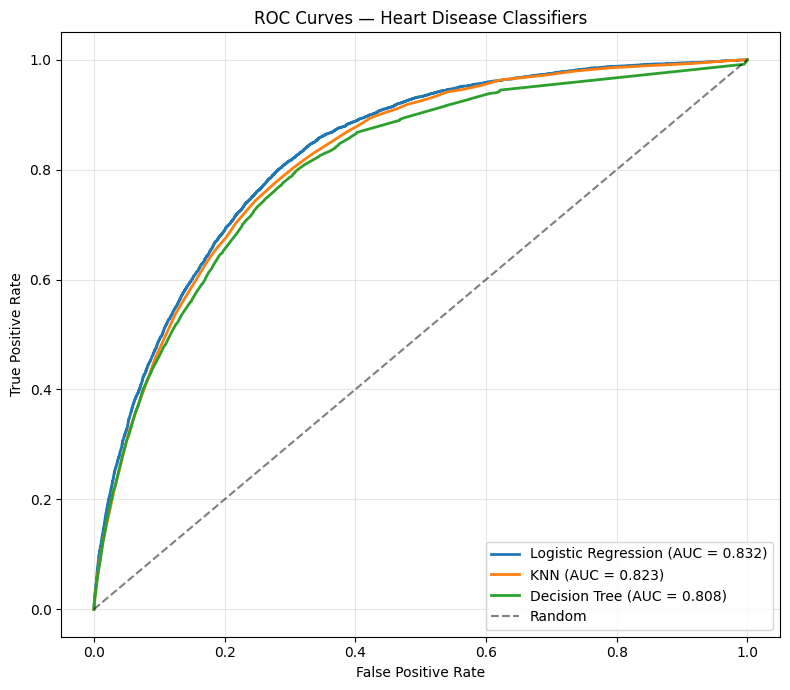

In [24]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC curves for all three models on one figure
fig, ax = plt.subplots(figsize=(8, 7))

for name, model, X_eval in [
    ("Logistic Regression", best_lr,  X_test_scaled),
    ("KNN",                 best_knn, X_test_scaled),
    ("Decision Tree",       best_dt,  X_test),
]:
    y_proba = model.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", linewidth=2)

ax.plot([0, 1], [0, 1], "k--", label="Random", alpha=0.5)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Heart Disease Classifiers")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
# Signed coefficients as sign tells us direction of effect, magnitude tells us strength.
# Sort by absolute magnitude to find the strongest predictors regardless of sign.
lr_coefs = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": best_lr.coef_[0],
    "abs_coef": np.abs(best_lr.coef_[0]),
}).sort_values("abs_coef", ascending=False)

print("Top 15 features by |coefficient| (Logistic Regression):")
print(lr_coefs[["feature", "coefficient"]].head(15).to_string(index=False))

Top 15 features by |coefficient| (Logistic Regression):
                feature  coefficient
AgeCategory_80 or older     0.756616
      AgeCategory_70-74     0.693266
      AgeCategory_75-79     0.641589
      AgeCategory_65-69     0.625484
      AgeCategory_60-64     0.544032
         GenHealth_Fair     0.464847
         GenHealth_Good     0.444583
      AgeCategory_55-59     0.439594
               Sex_Male     0.360032
         GenHealth_Poor     0.345747
      AgeCategory_50-54     0.330875
             Stroke_Yes     0.231301
    GenHealth_Very good     0.202619
      AgeCategory_45-49     0.194066
            Smoking_Yes     0.177839


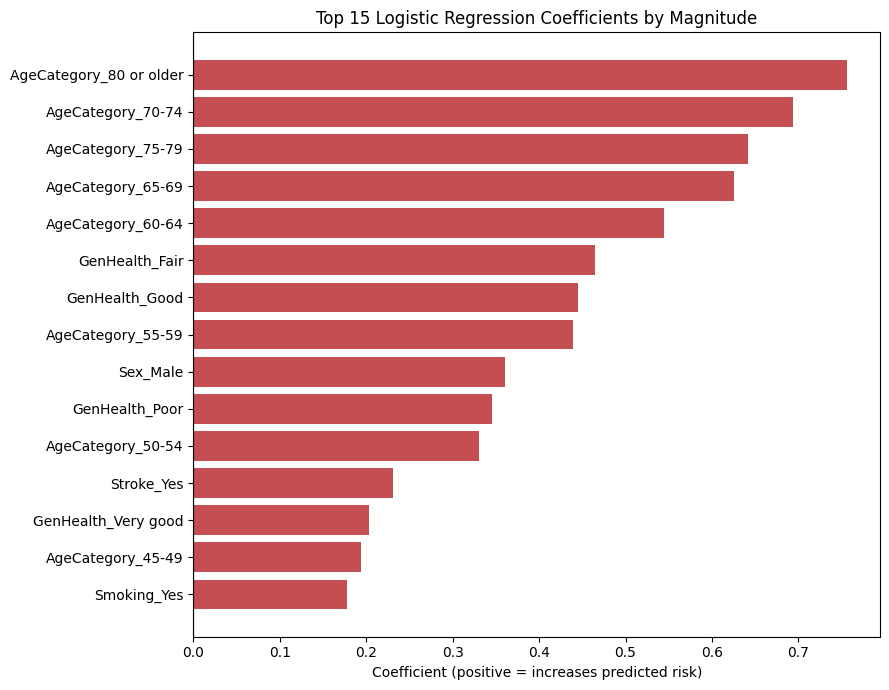

In [26]:
# Plot the top 15 coefficients colored by sign — red increases risk, blue decreases.
top_n = 15
top_lr = lr_coefs.head(top_n).sort_values("coefficient")

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#C44E52" if c > 0 else "#4C72B0" for c in top_lr["coefficient"]]
ax.barh(top_lr["feature"], top_lr["coefficient"], color=colors)
ax.set_xlabel("Coefficient (positive = increases predicted risk)")
ax.set_title(f"Top {top_n} Logistic Regression Coefficients by Magnitude")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("lr_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

Top 15 features by importance (Decision Tree):
                feature  importance
        DiffWalking_Yes    0.241774
           Diabetic_Yes    0.129274
AgeCategory_80 or older    0.095982
      AgeCategory_70-74    0.076231
      AgeCategory_75-79    0.066115
               Sex_Male    0.063806
             Stroke_Yes    0.056584
      AgeCategory_65-69    0.055297
      AgeCategory_60-64    0.041221
         GenHealth_Fair    0.032914
         GenHealth_Good    0.020712
      AgeCategory_55-59    0.020444
         GenHealth_Poor    0.017598
      AgeCategory_50-54    0.013269
                    BMI    0.011937


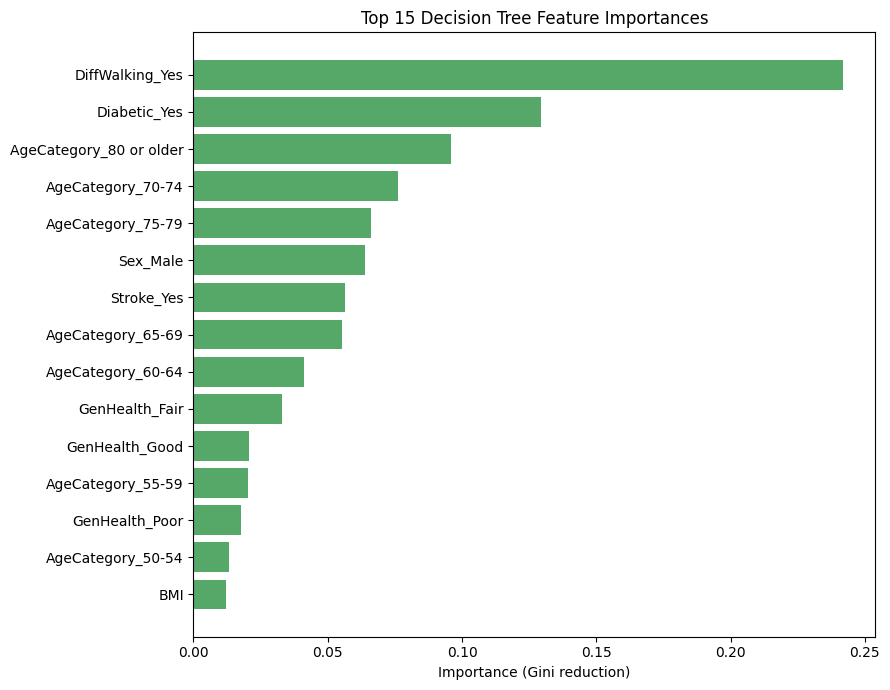

In [27]:
# Tree importance = total Gini reduction attributed to splits on this feature.
# Always non-negative — doesn't tell you direction, only "how often the tree relied on this."
dt_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_dt.feature_importances_,
}).sort_values("importance", ascending=False)

print("Top 15 features by importance (Decision Tree):")
print(dt_imp.head(15).to_string(index=False))

top_dt = dt_imp.head(15).sort_values("importance")
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_dt["feature"], top_dt["importance"], color="#55A868")
ax.set_xlabel("Importance (Gini reduction)")
ax.set_title("Top 15 Decision Tree Feature Importances")
plt.tight_layout()
plt.savefig("dt_importances.png", dpi=150, bbox_inches="tight")
plt.show()

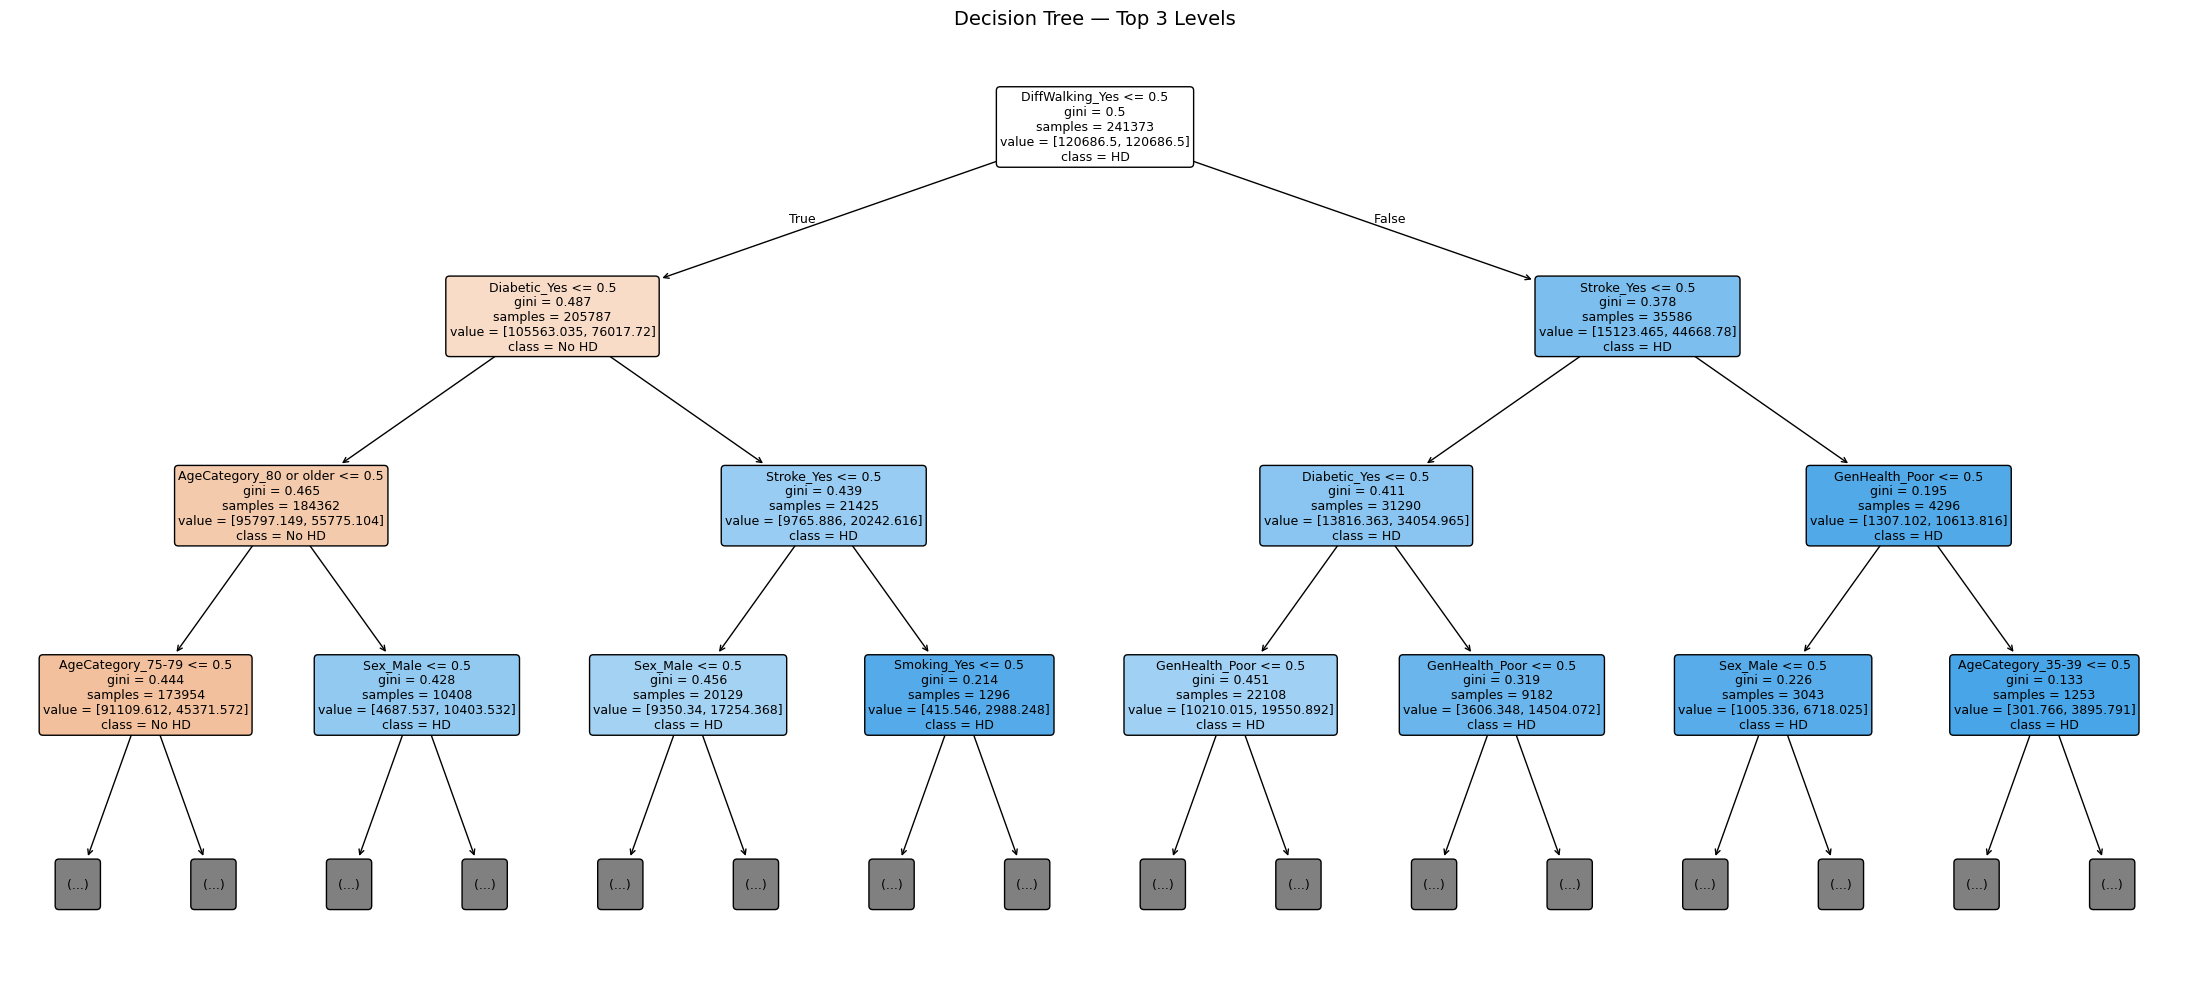

In [28]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Visualize the top of the tree so we can see how it splits.
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    best_dt,
    max_depth=3,
    feature_names=X_train.columns,
    class_names=["No HD", "HD"],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
)
ax.set_title("Decision Tree — Top 3 Levels", fontsize=14)
plt.tight_layout()
plt.savefig("decision_tree_top.png", dpi=150, bbox_inches="tight")
plt.show()

### Improved Models
We will now build the improved models

In [57]:
from sklearn.base import clone

# Stratified 80/20 split of training data. Same random_state on both calls
# means the same rows go to the same side in both scaled and unscaled splits.
X_tr_scaled, X_val_scaled, y_tr, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train,
)
X_tr, X_val, _, _ = train_test_split(
    X_train, y_train,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train,
)

print(f"Train inner: {X_tr_scaled.shape}, positive rate: {y_tr.mean():.4f}")
print(f"Validation:  {X_val_scaled.shape}, positive rate: {y_val.mean():.4f}")

Train inner: (193098, 37), positive rate: 0.0904
Validation:  (48275, 37), positive rate: 0.0904


In [60]:
def tune_threshold(model, X_val_data, y_val_data, X_test_data, y_test_data, name):
    """
    Pick threshold that maximizes F1 on validation, then apply ONCE to test.
    This is the clean version — test set never sees the threshold scan.
    """
    # Validation scan
    val_proba = model.predict_proba(X_val_data)[:, 1]
    thresholds = np.arange(0.05, 0.96, 0.02)
    val_f1s = [f1_score(y_val_data, (val_proba >= t).astype(int)) for t in thresholds]

    best_idx = int(np.argmax(val_f1s))
    best_t = thresholds[best_idx]
    val_f1 = val_f1s[best_idx]

    # Apply chosen threshold to test exactly once
    test_proba = model.predict_proba(X_test_data)[:, 1]
    test_pred = (test_proba >= best_t).astype(int)

    test_prec = precision_score(y_test_data, test_pred)
    test_rec  = recall_score(y_test_data, test_pred)
    test_f1   = f1_score(y_test_data, test_pred)

    print(f"\n{'=' * 60}")
    print(f"{name}")
    print('=' * 60)
    print(f"Threshold chosen on validation: {best_t:.2f}")
    print(f"Validation F1 at that threshold: {val_f1:.4f}")
    print(f"Test precision: {test_prec:.4f}")
    print(f"Test recall:    {test_rec:.4f}")
    print(f"Test F1:        {test_f1:.4f}")

    return {
        "model": name,
        "best_threshold": best_t,
        "val_f1": val_f1,
        "test_precision": test_prec,
        "test_recall": test_rec,
        "test_f1": test_f1,
    }

In [61]:
# Refit LR on the train-inner portion only (no validation leakage)
lr_clean = clone(best_lr)
lr_clean.fit(X_tr_scaled, y_tr)

lr_clean_result = tune_threshold(
    lr_clean, X_val_scaled, y_val, X_test_scaled, y_test, "Logistic Regression"
)


Logistic Regression
Threshold chosen on validation: 0.67
Validation F1 at that threshold: 0.3904
Test precision: 0.3018
Test recall:    0.5556
Test F1:        0.3911


In [62]:
# Refit DT on unscaled train-inner
dt_clean = clone(best_dt)
dt_clean.fit(X_tr, y_tr)

dt_clean_result = tune_threshold(
    dt_clean, X_val, y_val, X_test, y_test, "Decision Tree"
)


Decision Tree
Threshold chosen on validation: 0.71
Validation F1 at that threshold: 0.3732
Test precision: 0.3042
Test recall:    0.4958
Test F1:        0.3770


In [63]:
# KNN needs a balanced training set. Build it from train-inner only.
tr_combined = X_tr_scaled.copy()
tr_combined["target"] = y_tr.values

majority = tr_combined[tr_combined["target"] == 0]
minority = tr_combined[tr_combined["target"] == 1]
majority_down = majority.sample(n=len(minority), random_state=RANDOM_STATE)

balanced_inner = pd.concat([majority_down, minority]).sample(
    frac=1, random_state=RANDOM_STATE
)
X_tr_knn_clean = balanced_inner.drop("target", axis=1)
y_tr_knn_clean = balanced_inner["target"]

# Refit KNN on the balanced subset of train-inner
knn_clean = clone(best_knn)
knn_clean.fit(X_tr_knn_clean, y_tr_knn_clean)

knn_clean_result = tune_threshold(
    knn_clean, X_val_scaled, y_val, X_test_scaled, y_test, "KNN"
)


KNN
Threshold chosen on validation: 0.69
Validation F1 at that threshold: 0.3780
Test precision: 0.2988
Test recall:    0.5347
Test F1:        0.3834


In [64]:
# Compare three versions of the test F1 for each model:
# - Original tuned (threshold 0.5)
# - Threshold tuned on TEST (the previous version with leakage)
# - Threshold tuned on VALIDATION (this clean version)

comparison = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "original_F1 (threshold 0.5)": 0.3515,
        "threshold tuned on TEST (leaky)": 0.3941,
        "threshold tuned on VALIDATION (clean)": lr_clean_result["test_f1"],
        "clean threshold": lr_clean_result["best_threshold"],
    },
    {
        "model": "Decision Tree",
        "original_F1 (threshold 0.5)": 0.3313,
        "threshold tuned on TEST (leaky)": 0.3732,
        "threshold tuned on VALIDATION (clean)": dt_clean_result["test_f1"],
        "clean threshold": dt_clean_result["best_threshold"],
    },
    {
        "model": "KNN",
        "original_F1 (threshold 0.5)": 0.3407,
        "threshold tuned on TEST (leaky)": 0.3849,
        "threshold tuned on VALIDATION (clean)": knn_clean_result["test_f1"],
        "clean threshold": knn_clean_result["best_threshold"],
    },
]).set_index("model").round(4)

comparison

,original_F1 (threshold 0.5),threshold tuned on TEST (leaky),threshold tuned on VALIDATION (clean),clean threshold
model,,,,
Logistic Regression,0.3515,0.3941,0.3911,0.67
Decision Tree,0.3313,0.3732,0.3770,0.71
KNN,0.3407,0.3849,0.3834,0.69


In [65]:
from sklearn.metrics import accuracy_score

# Naïve LR — no class_weight, no C tuning, default 0.5 threshold
naive_lr = LogisticRegression(max_iter=1000)
naive_lr.fit(X_train_scaled, y_train)

# Naïve DT — no max_depth, no class_weight, default 0.5 threshold
naive_dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
naive_dt.fit(X_train, y_train)

# Naïve KNN — default k=5, uniform, no undersampling
print("Training naïve KNN on full training data — this will be slow...")
naive_knn = KNeighborsClassifier(n_jobs=-1)
naive_knn.fit(X_train_scaled, y_train)

print("\nAll three naïve baselines trained.")

Training naïve KNN on full training data — this will be slow...

All three naïve baselines trained.


In [66]:
def evaluate_with_accuracy(model, X_test_data, y_test_data, name):
    """Like the evaluate() function but also reports accuracy."""
    y_pred = model.predict(X_test_data)
    y_proba = model.predict_proba(X_test_data)[:, 1]

    acc  = accuracy_score(y_test_data, y_pred)
    prec = precision_score(y_test_data, y_pred, zero_division=0)
    rec  = recall_score(y_test_data, y_pred)
    f1   = f1_score(y_test_data, y_pred)
    auc  = roc_auc_score(y_test_data, y_proba)

    print(f"\n{'=' * 60}")
    print(f"NAÏVE BASELINE — {name}")
    print('=' * 60)
    print(f"Accuracy:  {acc:.4f}   <- potential trap")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}   ← matters clinically")
    print(f"F1:        {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"Confusion matrix:")
    print(confusion_matrix(y_test_data, y_pred))

    return {
        "model": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc_roc": auc,
    }


naive_results = []
naive_results.append(evaluate_with_accuracy(naive_lr,  X_test_scaled, y_test, "Logistic Regression"))
naive_results.append(evaluate_with_accuracy(naive_knn, X_test_scaled, y_test, "KNN"))
naive_results.append(evaluate_with_accuracy(naive_dt,  X_test,        y_test, "Decision Tree"))


NAÏVE BASELINE — Logistic Regression
Accuracy:  0.9112   ← looks impressive but is the trap
Precision: 0.5440
Recall:    0.1077   ← this is what actually matters clinically
F1:        0.1798
AUC-ROC:   0.8315
Confusion matrix:
[[54400   492]
 [ 4865   587]]

NAÏVE BASELINE — KNN
Accuracy:  0.8993   ← looks impressive but is the trap
Precision: 0.3610
Recall:    0.1484   ← this is what actually matters clinically
F1:        0.2103
AUC-ROC:   0.7129
Confusion matrix:
[[53460  1432]
 [ 4643   809]]

NAÏVE BASELINE — Decision Tree
Accuracy:  0.8543   ← looks impressive but is the trap
Precision: 0.2249
Recall:    0.2506   ← this is what actually matters clinically
F1:        0.2370
AUC-ROC:   0.5826
Confusion matrix:
[[50183  4709]
 [ 4086  1366]]


In [79]:
# We will build a side-by-side table showing Baseline vs Improved for each model.
# Uses existing variables: `results` (tuned + imbalance, threshold 0.5),
# and lr/dt/knn_clean_result (with threshold tuning).

# Tuned results from the original test-set evaluation cell (needed for AUC)
tuned_lr  = results[0]  # Logistic Regression
tuned_knn = results[1]  # KNN
tuned_dt  = results[2]  # Decision Tree

rows = []
for naive, tuned, clean, name in [
    (naive_results[0], tuned_lr,  lr_clean_result,  "Logistic Regression"),
    (naive_results[1], tuned_knn, knn_clean_result, "KNN"),
    (naive_results[2], tuned_dt,  dt_clean_result,  "Decision Tree"),
]:
    # Stage 1: The Naive Baseline
    rows.append({
        "Model": name, "Stage": "1. Baseline",
        "Precision": naive["precision"], "Recall": naive["recall"],
        "F1": naive["f1"], "AUC-ROC": naive["auc_roc"],
    })
    # Stage 2: The Fully Improved Model (Tuned + Balanced + Threshold Optimized)
    rows.append({
        "Model": name, "Stage": "2. Improved",
        "Precision": clean["test_precision"], "Recall": clean["test_recall"],
        "F1": clean["test_f1"], "AUC-ROC": tuned["auc_roc"],  # AUC unchanged by threshold
    })

baseline_vs_improved = pd.DataFrame(rows).round(4)
print("\n" + "=" * 80)
print("DIRECT BASELINE vs IMPROVED COMPARISON")
print("=" * 80)
display(baseline_vs_improved)



DIRECT BASELINE vs IMPROVED COMPARISON


,Model,Stage,Precision,Recall,F1,AUC-ROC
0,Logistic Regression,1. Baseline,0.5440,0.1077,0.1798,0.8315
1,Logistic Regression,2. Improved,0.3018,0.5556,0.3911,0.8320
2,KNN,1. Baseline,0.3610,0.1484,0.2103,0.7129
3,KNN,2. Improved,0.2988,0.5347,0.3834,0.8231
4,Decision Tree,1. Baseline,0.2249,0.2506,0.2370,0.5826
5,Decision Tree,2. Improved,0.3042,0.4958,0.3770,0.8076


### Presentation Visuals
These are the graphs and diagrams we will use to display the results of the models.

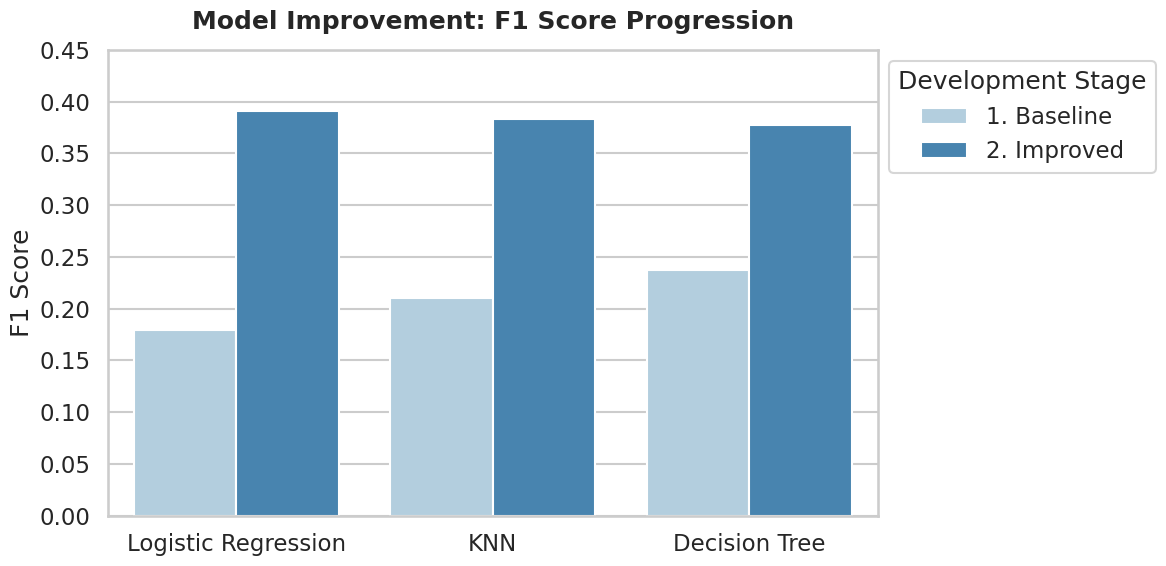

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style for clean, professional presentation visuals
sns.set_theme(style="whitegrid", context="talk")

# 1. F1 Score Progression Bar Chart
plt.figure(figsize=(12, 6))
ax = sns.barplot(x="Model", y="F1", hue="Stage", data=baseline_vs_improved, palette="Blues")
plt.title("Model Improvement: F1 Score Progression", fontsize=18, fontweight='bold', pad=15)
plt.ylabel("F1 Score")
plt.xlabel("")
plt.ylim(0, 0.45)
plt.legend(title="Development Stage", loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig("presentation_f1_progression.png", dpi=300)
plt.show()

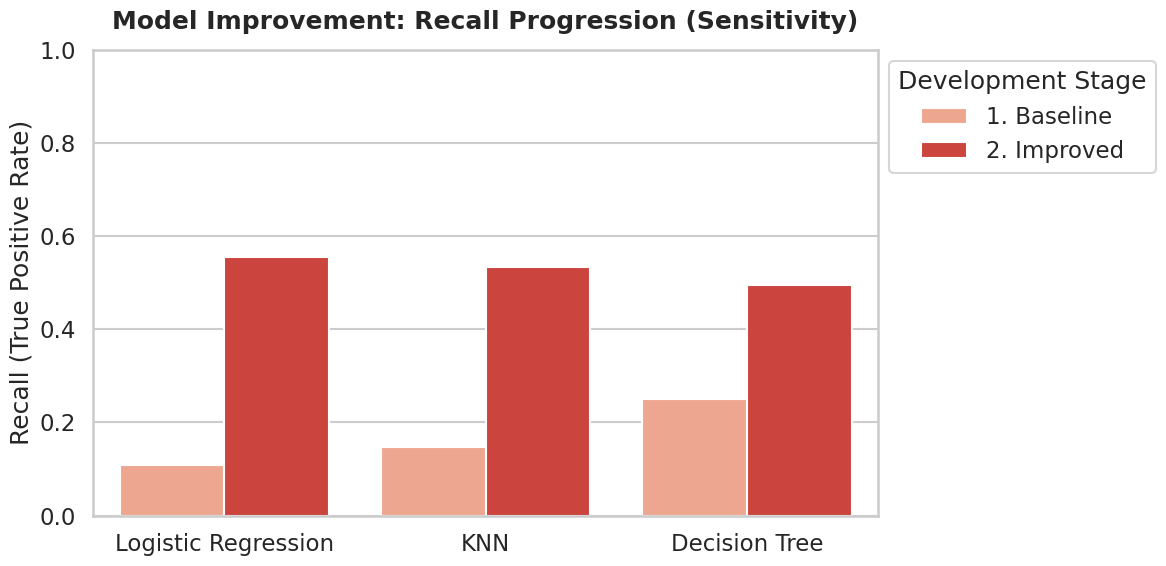

In [81]:
# 2. Recall Progression Bar Chart (Clinical Importance)
plt.figure(figsize=(12, 6))
ax2 = sns.barplot(x="Model", y="Recall", hue="Stage", data=baseline_vs_improved, palette="Reds")
plt.title("Model Improvement: Recall Progression (Sensitivity)", fontsize=18, fontweight='bold', pad=15)
plt.ylabel("Recall (True Positive Rate)")
plt.xlabel("")
plt.ylim(0, 1.0)
plt.legend(title="Development Stage", loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig("presentation_recall_progression.png", dpi=300)
plt.show()

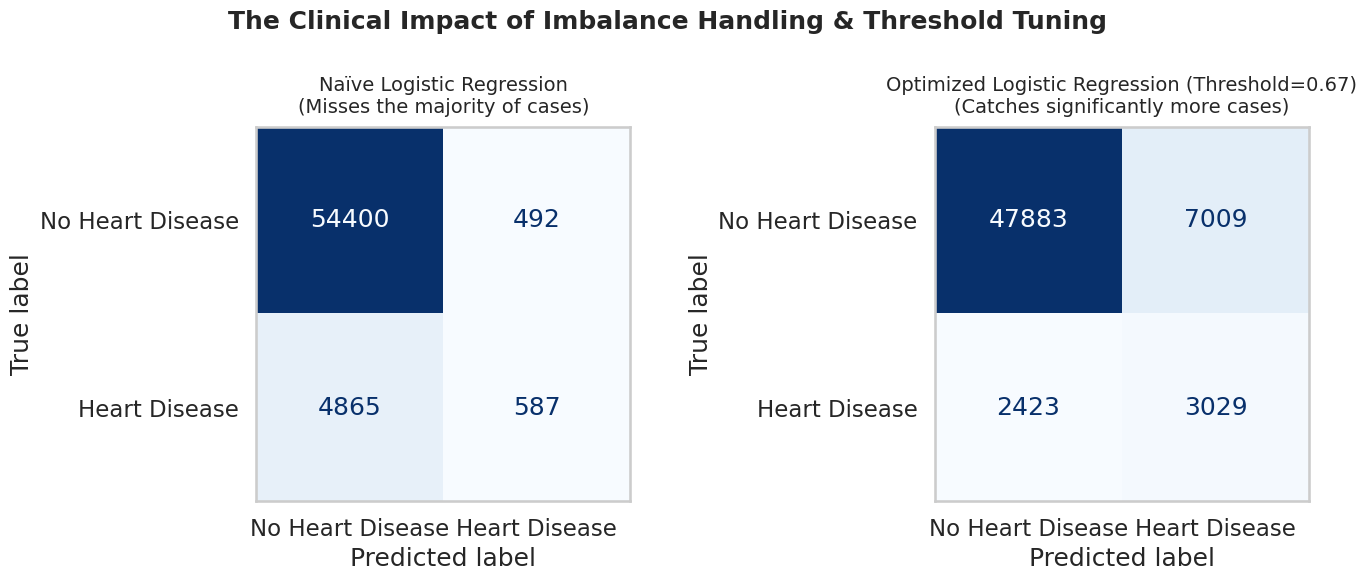

In [82]:
from sklearn.metrics import ConfusionMatrixDisplay

# 3. Side-by-Side Confusion Matrix: Naive vs. Optimized (Logistic Regression)
# Generate predictions for the final threshold-tuned model
final_lr_threshold = lr_clean_result["best_threshold"]
y_proba_clean_lr = lr_clean.predict_proba(X_test_scaled)[:, 1]
y_pred_clean_lr = (y_proba_clean_lr >= final_lr_threshold).astype(int)

# Get Naive predictions
y_pred_naive_lr = naive_lr.predict(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Naive Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_naive_lr,
    display_labels=["No Heart Disease", "Heart Disease"],
    cmap="Blues", ax=axes[0], colorbar=False
)
axes[0].set_title("Naïve Logistic Regression\n(Misses the majority of cases)", fontsize=14, pad=10)
axes[0].grid(False)

# Optimized Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_clean_lr,
    display_labels=["No Heart Disease", "Heart Disease"],
    cmap="Blues", ax=axes[1], colorbar=False
)
axes[1].set_title(f"Optimized Logistic Regression (Threshold={final_lr_threshold:.2f})\n(Catches significantly more cases)", fontsize=14, pad=10)
axes[1].grid(False)

plt.suptitle("The Clinical Impact of Imbalance Handling & Threshold Tuning", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig("presentation_confusion_matrix_comparison.png", dpi=300)
plt.show()

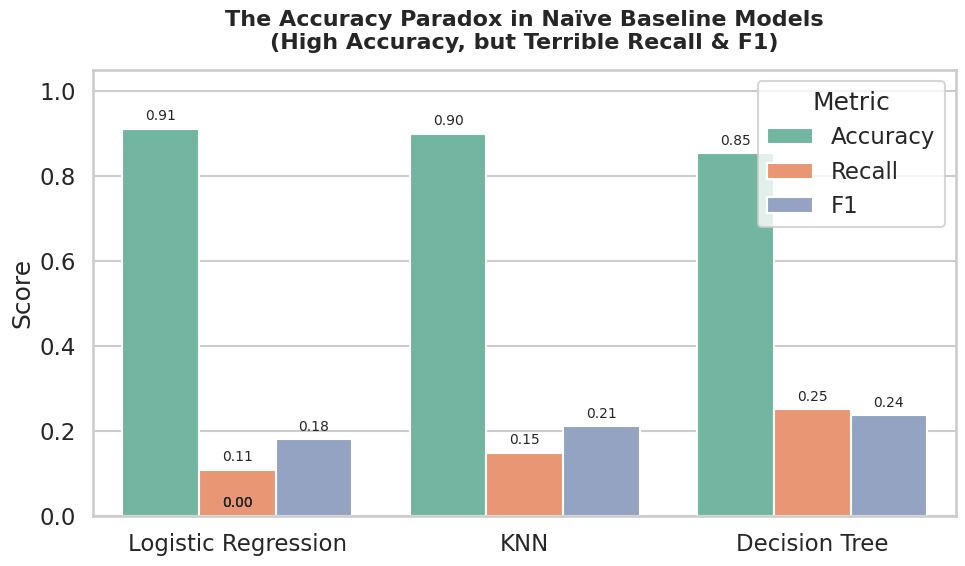

In [84]:
# 4. The Accuracy issue: Naive Baseline Performance
# we Extract the naive metrics to show why Accuracy is a misleading metric here
naive_df = pd.DataFrame(naive_results)
naive_df_melted = naive_df.melt(id_vars="model", value_vars=["accuracy", "recall", "f1"],
                                var_name="Metric", value_name="Score")
naive_df_melted["Metric"] = naive_df_melted["Metric"].str.capitalize()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x="model", y="Score", hue="Metric", data=naive_df_melted, palette="Set2")
plt.title("The Accuracy Paradox in Naïve Baseline Models\n(High Accuracy, but Terrible Recall & F1)", fontsize=16, fontweight='bold', pad=15)
plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0, 1.05)

# Add values on top of bars for emphasis
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=10)

plt.legend(title="Metric", loc='upper right')
plt.tight_layout()
plt.savefig("presentation_naive_baseline_metrics.png", dpi=300)
plt.show()

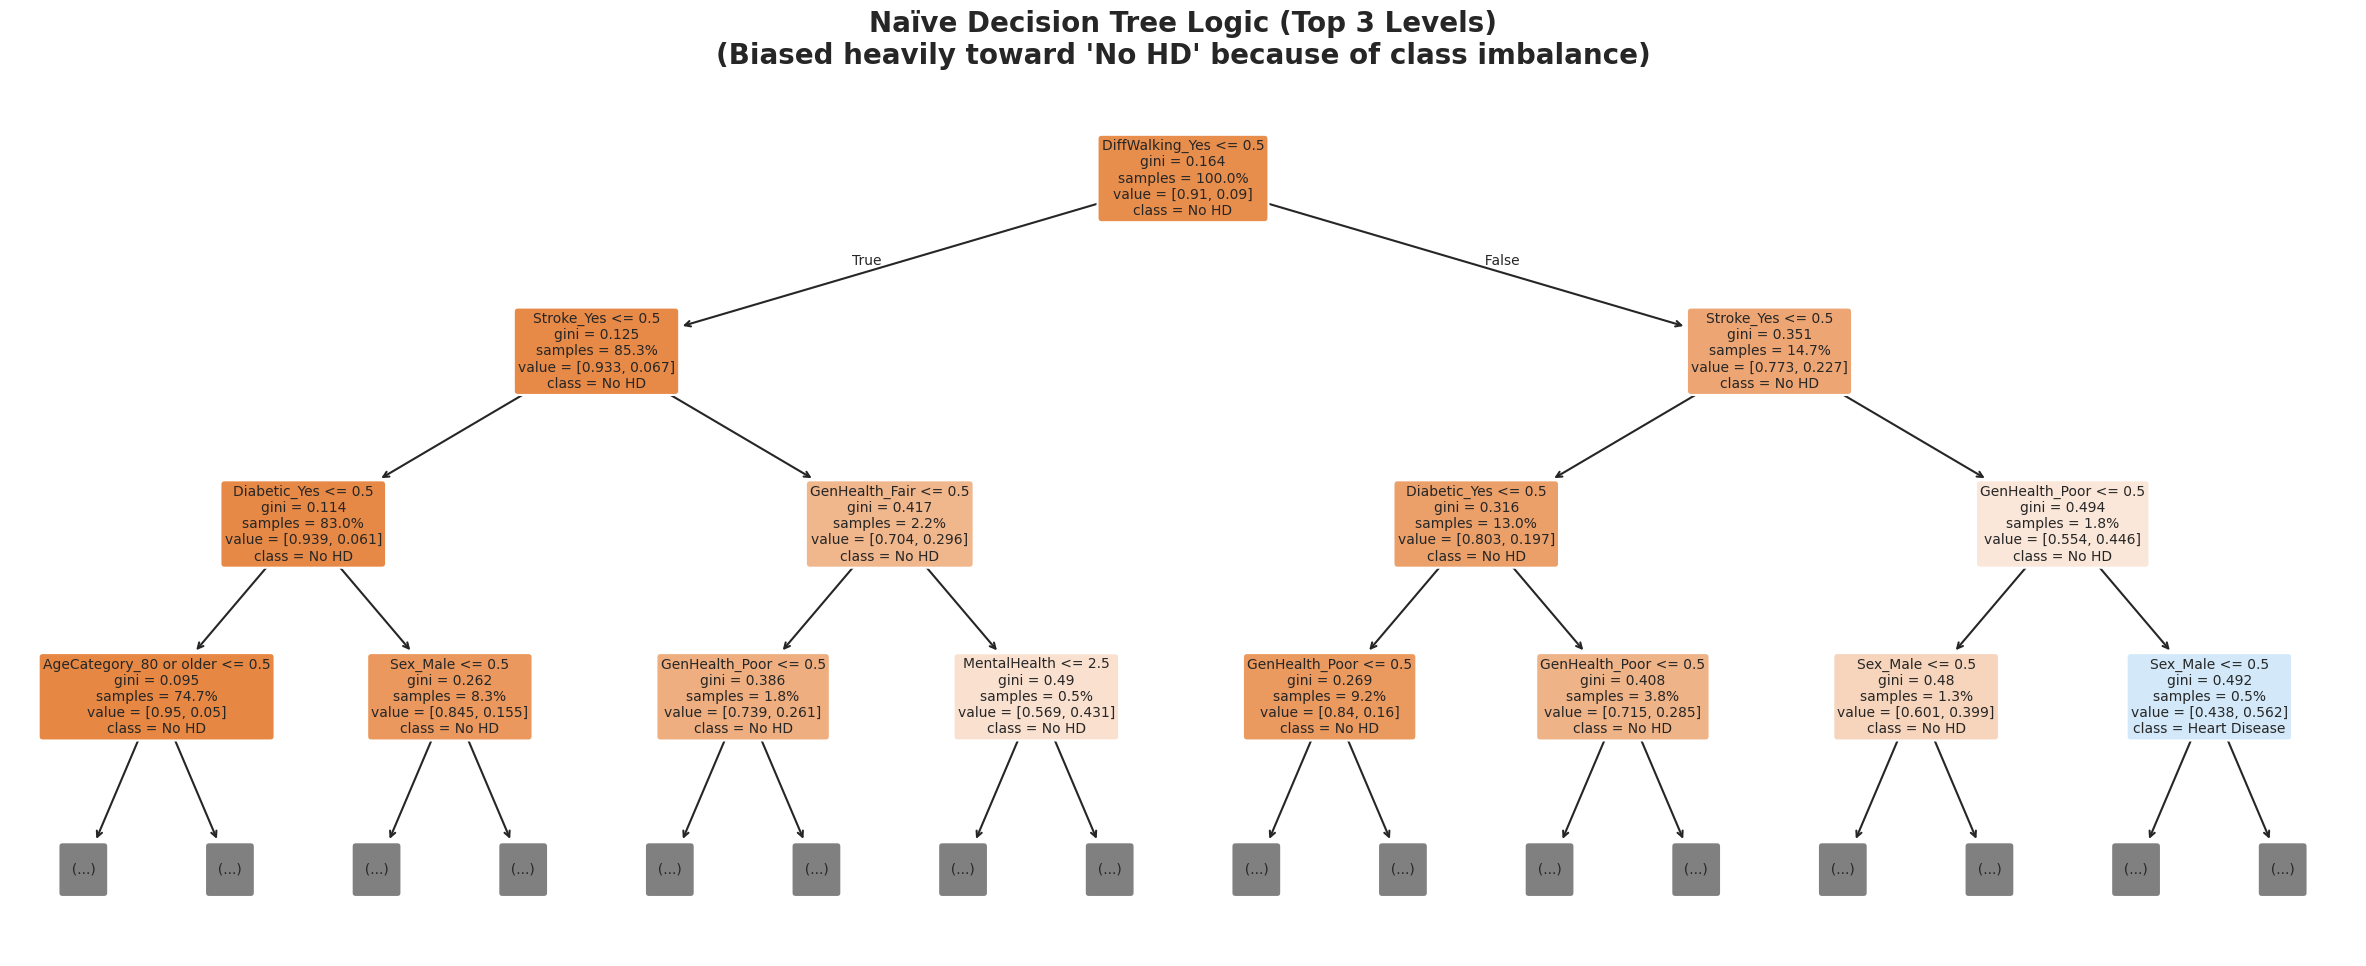

In [85]:
from sklearn.tree import plot_tree

# 5. Decision Tree Visualizations
# First, the Naive Decision Tree (Unbalanced, no max depth)
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    naive_dt,
    max_depth=3, # Only show top 3 levels to avoid unreadable mess
    feature_names=X_train.columns,
    class_names=["No HD", "Heart Disease"],
    filled=True,
    rounded=True,
    fontsize=10,
    proportion=True,
    ax=ax,
)
plt.title("Naïve Decision Tree Logic (Top 3 Levels)\n(Biased heavily toward 'No HD' because of class imbalance)", fontsize=20, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("presentation_naive_decision_tree.png", dpi=300)
plt.show()

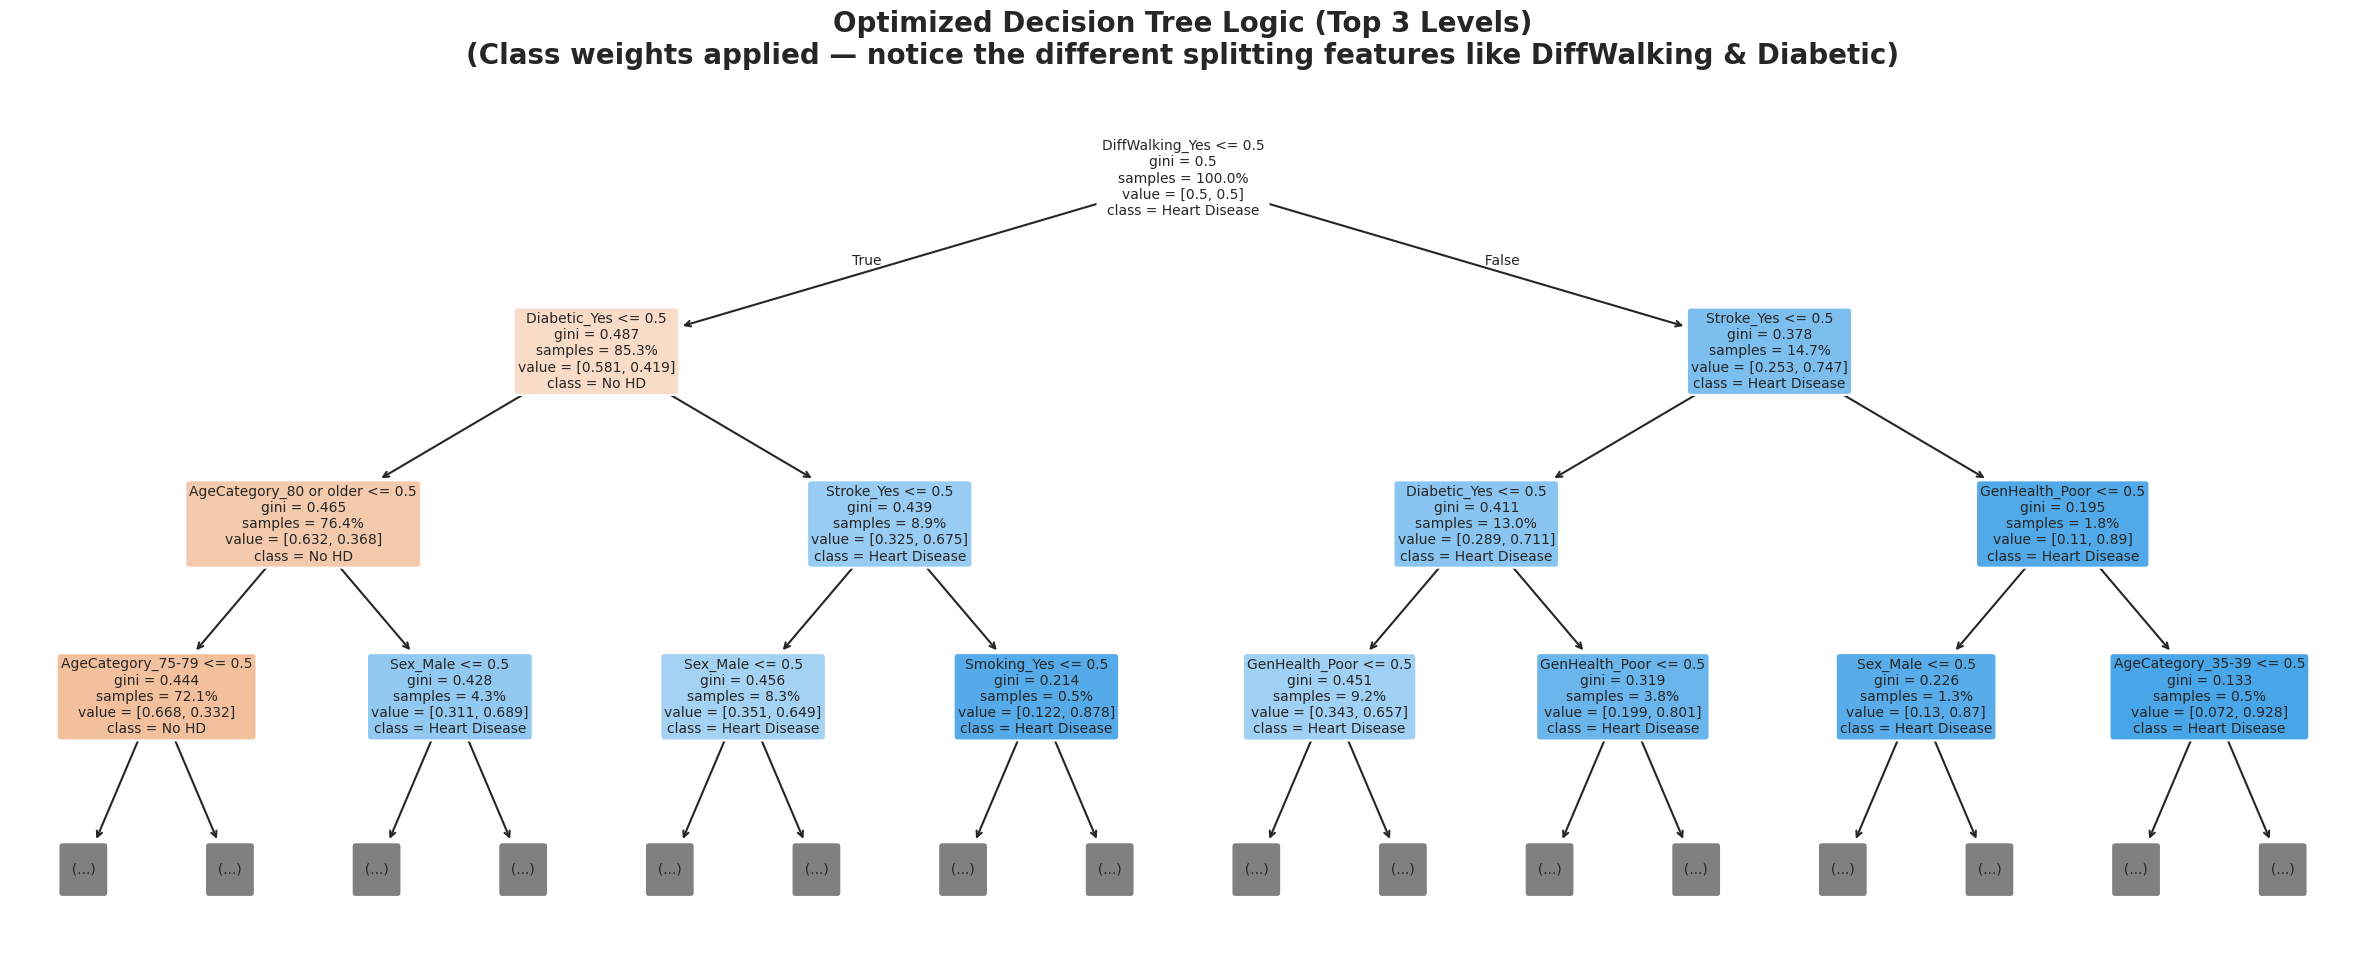

In [86]:
# 6. The Optimized Decision Tree (Balanced, tuned depth)
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    best_dt,
    max_depth=3,
    feature_names=X_train.columns,
    class_names=["No HD", "Heart Disease"],
    filled=True,
    rounded=True,
    fontsize=10,
    proportion=True,
    ax=ax,
)
plt.title("Optimized Decision Tree Logic (Top 3 Levels)\n(Class weights applied — notice the different splitting features like DiffWalking & Diabetic)", fontsize=20, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("presentation_optimized_decision_tree.png", dpi=300)
plt.show()